Mounted at /content/drive
📥 Đang clone repository...
✅ Clone thành công!
📖 Đang đọc file JSONL...
Dòng 1: {"text": "the menu looked great, but the food was the biggest disappointment i've had yet!", "labels": [{"aspect": "menu", "polarity": "positive"}, {"aspect": "food", "polarity": "negative"}]}...
Dòng 2: {"text": "Pros : - Great sound for a $ 100 speaker at mid to higher levels .", "labels": [{"aspect": "sound", "polarity": "positive"}]}...
Dòng 3: {"text": "Service was friendly, but not terribly attentive, took 30 minutes after dinner to clear our plates, and another 20 to get our check.", "labels": [{"aspect": "Service", "polarity": "positive"...
📊 Tổng số câu gốc: 16127
📊 Số cặp (câu, aspect) sau xử lý: 30813
🔍 5 dòng đầu tiên:
                                                text   aspect sentiment
0  the menu looked great, but the food was the bi...     menu  positive
1  the menu looked great, but the food was the bi...     food  negative
2  Pros : - Great sound for a $ 100 spe

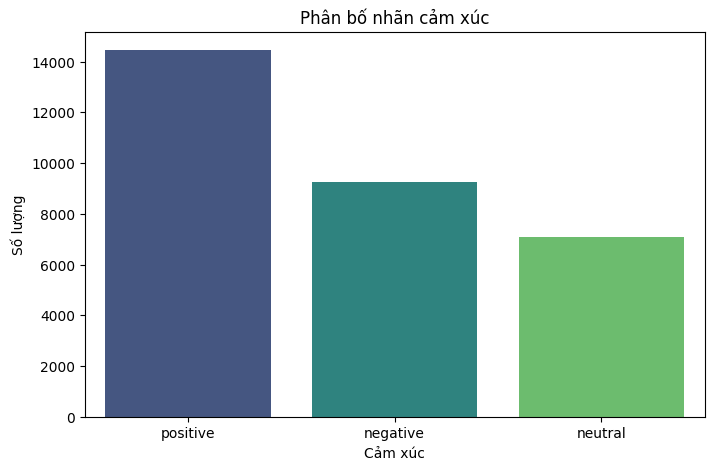


✅ Train size: 24650 | Test size: 6163


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

🚀 Sử dụng thiết bị: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



⏳ Bắt đầu huấn luyện (5 epochs)...
Epoch 1/5 | Loss: 0.4973
Epoch 2/5 | Loss: 0.2807
Epoch 3/5 | Loss: 0.1609
Epoch 4/5 | Loss: 0.0956
Epoch 5/5 | Loss: 0.0702

📊 BÁO CÁO KẾT QUẢ TRÊN TẬP TEST:
              precision    recall  f1-score   support

    negative       0.85      0.88      0.87      1852
     neutral       0.82      0.78      0.80      1420
    positive       0.90      0.91      0.90      2891

    accuracy                           0.87      6163
   macro avg       0.86      0.85      0.86      6163
weighted avg       0.87      0.87      0.87      6163



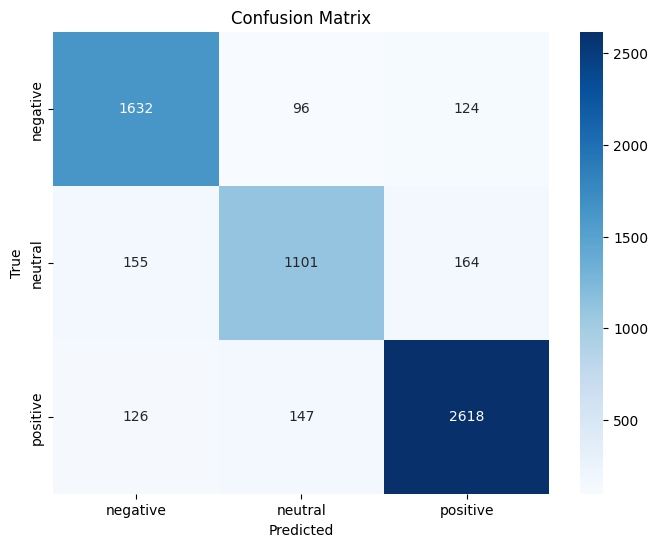

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Mô hình và tokenizer đã được lưu vào: /content/drive/MyDrive/absa_bert_model

🔮 DỰ ĐOÁN MẪU:
'The screen is amazing but the battery is terrible.' | Aspect: screen -> positive
'The screen is amazing but the battery is terrible.' | Aspect: battery -> negative
'The food was delicious, but service was slow.' | Aspect: food -> positive
'The food was delicious, but service was slow.' | Aspect: service -> negative


In [ ]:
# ==================== 1. Kết nối Google Drive & cài thư viện ====================
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers torch pandas numpy scikit-learn matplotlib seaborn

import os
import json
import subprocess
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==================== 2. Tải dữ liệu từ GitHub ====================
repo_url = "https://github.com/ThanosDiam/ABSA-Analysis-with-Explainability-Methods.git"
repo_path = "ABSA-Analysis-with-Explainability-Methods"
dataset_file = "FINAL_CLEANED_CORRECTED_SHUFFLED_DATASET_NO_DUPLICATE.jsonl"

if not os.path.exists(repo_path):
    print("📥 Đang clone repository...")
    subprocess.run(["git", "clone", repo_url], check=True)
    print("✅ Clone thành công!")
else:
    print("✅ Repository đã có sẵn.")

file_path = os.path.join(repo_path, "Datasets", dataset_file)
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Không tìm thấy file {file_path}")

# ==================== 3. Đọc và phân tích cấu trúc dữ liệu ====================
print("📖 Đang đọc file JSONL...")
data = []
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i < 3:
            print(f"Dòng {i+1}: {line.strip()[:200]}...")  # in 200 ký tự đầu
        if line.strip():
            data.append(json.loads(line))

print(f"📊 Tổng số câu gốc: {len(data)}")

# Hàm phát hiện key phù hợp
def extract_triplets(item):
    """Trích xuất (text, aspect, sentiment) từ item JSON với nhiều cấu trúc khả dĩ."""
    # Trường hợp 1: có 'sentence' và 'aspects'
    if 'sentence' in item and 'aspects' in item:
        sent = item['sentence']
        for asp in item['aspects']:
            term = asp.get('term', '')
            pol = asp.get('polarity', '')
            if term and pol in ['positive','negative','neutral']:
                yield (sent, term, pol)
        return
    # Trường hợp 2 (MỚI): có 'text' và 'labels' (dạng list các dict)
    if 'text' in item and 'labels' in item and isinstance(item['labels'], list):
        sent = item['text']
        for label_entry in item['labels']:
            term = label_entry.get('aspect', '')
            pol = label_entry.get('polarity', '')
            if term and pol in ['positive','negative','neutral']:
                yield (sent, term, pol)
        return
    # Trường hợp 3: có 'text', 'aspect', 'sentiment'
    if 'text' in item and 'aspect' in item and 'sentiment' in item:
        yield (item['text'], item['aspect'], item['sentiment'])
        return
    # Trường hợp 4: có 'review', 'term', 'polarity'
    if 'review' in item and 'term' in item and 'polarity' in item:
        yield (item['review'], item['term'], item['polarity'])
        return
    # Trường hợp 5: có 'sentence', 'term', 'polarity'
    if 'sentence' in item and 'term' in item and 'polarity' in item:
        yield (item['sentence'], item['term'], item['polarity'])
        return

records = []
for item in data:
    for text, aspect, sentiment in extract_triplets(item):
        records.append(
            {
                'text': text,
                'aspect': aspect,
                'sentiment': sentiment.lower().strip()
            }
        )

df = pd.DataFrame(records)
print(f"📊 Số cặp (câu, aspect) sau xử lý: {len(df)}")
if df.empty:
    print("⚠️ Không tìm thấy cặp nào. Hãy kiểm tra lại cấu trúc file JSONL.")
    print("Mẫu một item đầu tiên:", data[0] if data else "Không có dữ liệu")
    raise SystemExit

print("🔍 5 dòng đầu tiên:")
print(df.head())

# Thống kê nhãn
print("\n📈 Phân bố nhãn:")
print(df['sentiment'].value_counts())

# Vẽ biểu đồ
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sentiment', order=['positive', 'negative', 'neutral'], palette='viridis')
plt.title('Phân bố nhãn cảm xúc')
plt.xlabel('Cảm xúc')
plt.ylabel('Số lượng')
plt.show()

# ==================== 4. Tiền xử lý cho BERT ====================
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f"\n✅ Train size: {len(train_df)} | Test size: {len(test_df)}")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class ABSADataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = str(self.data.iloc[idx]['text'])
        aspect = str(self.data.iloc[idx]['aspect'])
        label = self.data.iloc[idx]['label']

        encoding = self.tokenizer(
            text, aspect,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = ABSADataset(train_df, tokenizer)
test_dataset = ABSADataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# ==================== 5. Khởi tạo mô hình BERT ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Sử dụng thiết bị: {device}")

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

# ==================== 6. Huấn luyện ====================
def train_epoch():
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

epochs = 5
print("\n⏳ Bắt đầu huấn luyện (5 epochs)...")
for epoch in range(epochs):
    loss = train_epoch()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f}")

# ==================== 7. Đánh giá ====================
model.eval()
predictions, true_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

target_names = ['negative', 'neutral', 'positive']
print("\n📊 BÁO CÁO KẾT QUẢ TRÊN TẬP TEST:")
print(classification_report(true_labels, predictions, target_names=target_names))

# Ma trận nhầm lẫn
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ==================== 8. Lưu mô hình vào Google Drive ====================
save_path = "/content/drive/MyDrive/absa_bert_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"\n✅ Mô hình và tokenizer đã được lưu vào: {save_path}")

# ==================== 9. Demo dự đoán ====================
def predict_sentiment(text, aspect):
    model.eval()
    encoding = tokenizer(text, aspect, return_tensors='pt', truncation=True, padding='max_length', max_length=128)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    with torch.no_grad():
        logits = model(input_ids, attention_mask=attention_mask).logits
        pred = torch.argmax(logits, dim=1).item()
    return target_names[pred]

print("\n🔮 DỰ ĐOÁN MẪU:")
examples = [
    ("The screen is amazing but the battery is terrible.", "screen"),
    ("The screen is amazing but the battery is terrible.", "battery"),
    ("The food was delicious, but service was slow.", "food"),
    ("The food was delicious, but service was slow.", "service"),
]
for text, asp in examples:
    res = predict_sentiment(text, asp)
    print(f"'{text}' | Aspect: {asp} -> {res}")

In [ ]:
print('Kiểm tra nội dung thư mục lưu mô hình trên Google Drive:')
!ls -F "/content/drive/MyDrive/absa_bert_model"

Kiểm tra nội dung thư mục lưu mô hình trên Google Drive:
ls: cannot access '/content/drive/MyDrive/absa_bert_model': No such file or directory
